# Quasi Monte Carlo convergence testing

Function initialization:

In [2]:
from QMC_option_pricing import european_call_cf, european_call_mc, european_call_at

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import time

def linfit(X,Y):
    logx = np.log(X)
    logY = np.log(Y)

    # linear fit: logY = a * logx + logC
    a, logC = np.polyfit(logx, logY, 1)

    C = np.exp(logC)
    return a, C
    

%matplotlib inline

Variable initialization:

Change these values to see how they affect the simulation

In [3]:
S0 = 100      # spot
K = 100       # at-the-money strike
T = 1       # 1 year
r = 0.05      # 5% risk-free rate
sigma = 0.20  # 20% volatility
maxiter = 7
exp = 100
confidence = 0.95

CF_price = european_call_cf(S0,K,T,r,sigma) # Exact value

The following code will generate expected returns using the Quasi Monte Carlo european option pricing, using antithetic variates, to test the convergence rate. A moderate estimate for volatility and interest rate is used. The least squares aproximation for a linear fit on the log-log plot is used, to fit the obtained error to $Cx^{a}$. The 95% confidence intervals are shown.

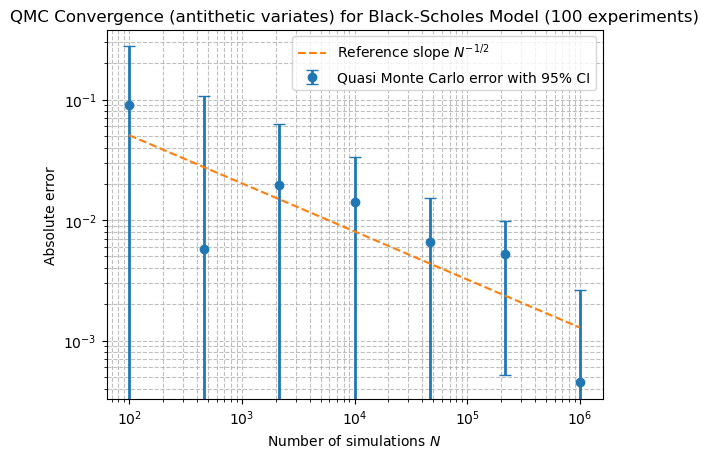

Fitting line: 0.32x^-0.40


In [21]:
QMC_price = np.zeros(maxiter)
CI = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    prices = european_call_at(S0, K, T, r, sigma, n, exp)
    mean = np.mean(prices)
    QMC_price[i] = mean

    # CI calculation
    sem = np.std(prices, ddof=1) / np.sqrt(exp)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=exp - 1)
    CI[i] = t_crit * sem

E = np.abs(QMC_price - CF_price)

plt.errorbar(N,E,yerr=CI,fmt='o',lw=2,capsize=4,label=f'Quasi Monte Carlo error with {100*confidence:.0f}% CI')

a,C = linfit(N,E)
ref = C * N**a

plt.loglog(N,ref,'--',label=r'Reference slope $N^{-1/2}$')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute error')
plt.title(f'QMC Convergence (antithetic variates) for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()

print(f"Fitting line: {C:.2f}x^{a:.2f}")

Moreover, the defining metrics for QMC can be obtained. Note how bias estimates are much more susceptible to noise, as the difference between two really close magnitudes is being measured. The linear (in log-log) fit is also shown.

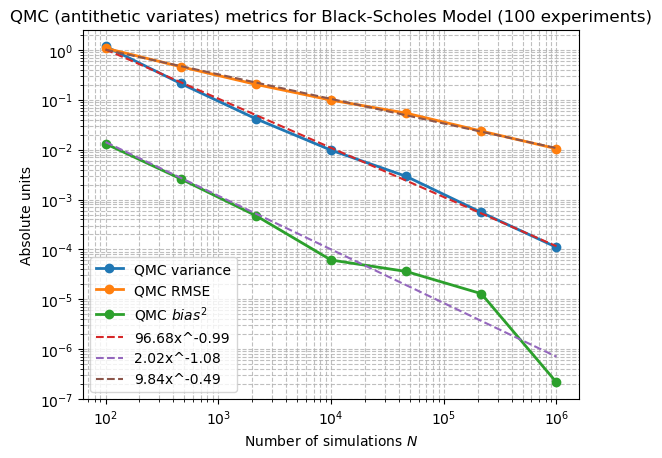

In [4]:
QMC_bias = np.zeros(maxiter)
QMC_variance = np.zeros(maxiter)
QMC_RMSE = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    price = european_call_at(S0, K, T, r, sigma, n, exp)
    QMC_bias[i] = np.mean(price) - CF_price
    QMC_variance[i] = np.var(price, ddof=1)
    QMC_RMSE[i] = np.sqrt(np.mean((price - CF_price)**2))

plt.loglog(N,QMC_variance,'o-',lw=2,label='QMC variance')
plt.loglog(N,QMC_RMSE,'o-',lw=2,label='QMC RMSE')
plt.loglog(N,QMC_bias**2,'o-',lw=2,label='QMC $bias^2$')

a,C = linfit(N,QMC_variance)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

a,C = linfit(N,QMC_bias**2)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

a,C = linfit(N,QMC_RMSE)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'QMC (antithetic variates) metrics for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()


Also, both the computation time and variance can be compared for Monte Carlo and antithetic variates Monte Carlo. Theoretically, antithetic variates should have both lower variance and computation time.

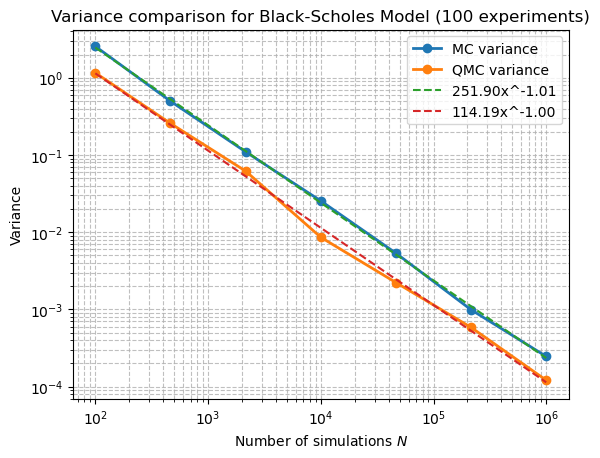

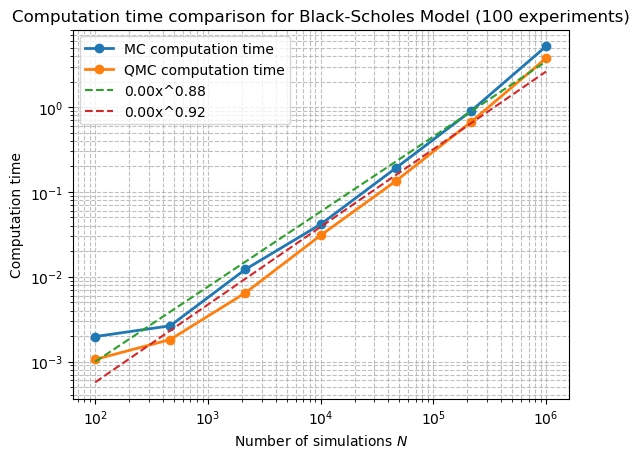

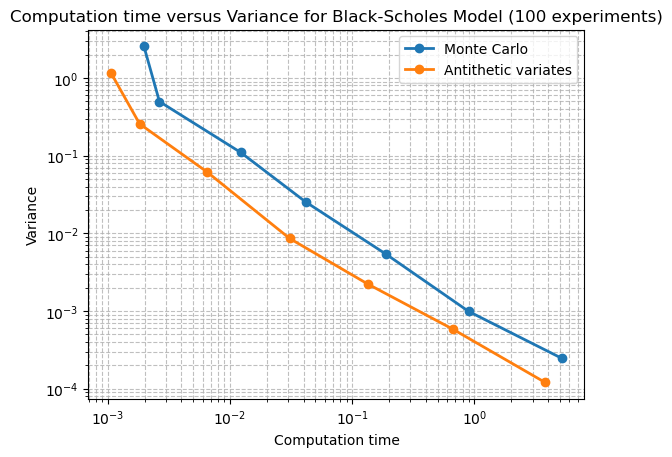

Variance reduction factor: 2.14


In [10]:
MC_variance = np.zeros(maxiter)
MC_time = np.zeros(maxiter)
QMC_variance = np.zeros(maxiter)
QMC_time = np.zeros(maxiter)
N = np.logspace(2, maxiter-1, maxiter, dtype=int)

for i, n in enumerate(N):
    start = time.perf_counter()
    price = european_call_mc(S0, K, T, r, sigma, n, exp)
    MC_time[i] = time.perf_counter() - start
    MC_variance[i] = np.var(price, ddof=1)

    start = time.perf_counter()
    price = european_call_at(S0, K, T, r, sigma, n, exp)
    QMC_time[i] = time.perf_counter() - start
    QMC_variance[i] = np.var(price, ddof=1)

# Variance plot

plt.loglog(N,MC_variance,'o-',lw=2,label='MC variance')
plt.loglog(N,QMC_variance,'o-',lw=2,label='QMC variance')

a,C = linfit(N,MC_variance)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

a,C = linfit(N,QMC_variance)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Variance')
plt.title(f'Variance comparison for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()

# Computation time plot

plt.loglog(N,MC_time,'o-',lw=2,label='MC computation time')
plt.loglog(N,QMC_time,'o-',lw=2,label='QMC computation time')

a,C = linfit(N,MC_time)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

a,C = linfit(N,QMC_time)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.2f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Computation time')
plt.title(f'Computation time comparison for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()

# Variance vs computation time

plt.loglog(MC_time,MC_variance, 'o-',lw=2,label='Monte Carlo')
plt.loglog(QMC_time,QMC_variance, 'o-',lw=2,label='Antithetic variates')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Computation time')
plt.ylabel('Variance')
plt.title(f'Computation time versus Variance for Black-Scholes Model ({exp} experiments)')
plt.legend()
plt.show()

var_red_factor = np.mean (MC_variance/QMC_variance)
print(f"Variance reduction factor: {var_red_factor:.2f}")